In [13]:
!pip install transformers datasets torch scikit-learn

In [14]:
# Import necessary dependencies
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, AutoModelForMaskedLM
from datasets import load_dataset, DatasetDict
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from transformers import AutoModelForSequenceClassification, DataCollatorForLanguageModeling, Trainer
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_recall_curve
import seaborn as sns
import os

In [22]:
# Set device for GPU usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [23]:
# Load LEDGAR dataset
dataset = load_dataset('lex_glue', 'ledgar')

# Display dataset features
print(dataset['train'].features)

{'text': Value('string'), 'label': ClassLabel(names=['Adjustments', 'Agreements', 'Amendments', 'Anti-Corruption Laws', 'Applicable Laws', 'Approvals', 'Arbitration', 'Assignments', 'Assigns', 'Authority', 'Authorizations', 'Base Salary', 'Benefits', 'Binding Effects', 'Books', 'Brokers', 'Capitalization', 'Change In Control', 'Closings', 'Compliance With Laws', 'Confidentiality', 'Consent To Jurisdiction', 'Consents', 'Construction', 'Cooperation', 'Costs', 'Counterparts', 'Death', 'Defined Terms', 'Definitions', 'Disability', 'Disclosures', 'Duties', 'Effective Dates', 'Effectiveness', 'Employment', 'Enforceability', 'Enforcements', 'Entire Agreements', 'Erisa', 'Existence', 'Expenses', 'Fees', 'Financial Statements', 'Forfeitures', 'Further Assurances', 'General', 'Governing Laws', 'Headings', 'Indemnifications', 'Indemnity', 'Insurances', 'Integration', 'Intellectual Property', 'Interests', 'Interpretations', 'Jurisdictions', 'Liens', 'Litigations', 'Miscellaneous', 'Modifications'

In [24]:
# Get label information
label_list = dataset['train'].features['label'].names
num_labels = len(label_list)
print(f"Number of labels: {num_labels}")

Number of labels: 100


In [25]:
{
 "text": "Executive agrees to be employed with the Company, and the Company agrees to employ Executive, during the Term and on the terms and conditions set forth in this Agreement. Executive agrees during the term of this Agreement to devote substantially all of Executive’s business time, efforts, skills and abilities to the performance of Executive’s duties ...",
 "label": "Employment"
}

{'text': 'Executive agrees to be employed with the Company, and the Company agrees to employ Executive, during the Term and on the terms and conditions set forth in this Agreement. Executive agrees during the term of this Agreement to devote substantially all of Executive’s business time, efforts, skills and abilities to the performance of Executive’s duties ...',
 'label': 'Employment'}

In [26]:
# Create mappings from label names to indices and vice versa
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for idx, label in enumerate(label_list)}

In [28]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained('nlpaueb/legal-bert-base-uncased')

# Token length computation function
def compute_token_lengths(example):
 tokens = tokenizer.encode(example['text'], add_special_tokens=True)
 example['num_tokens'] = len(tokens)
 return example

# Apply token length computation to the dataset
# dataset = dataset.map(compute_token_lengths) # This was for LEDGAR, not needed for Eurlex

def preprocess_data(examples):
 # Tokenize the texts
 encoding = tokenizer(
 examples['text'],
 truncation=True, # Truncate texts longer than max_length
 padding='max_length', # Pad texts shorter than max_length
 max_length=512
 )

 # Convert labels to multi-hot encoding
 num_labels = len(dataset['train'].features['label'].names) # Changed 'labels' to 'label'
 labels_batch = examples['label'] # Changed 'labels' to 'label'
 labels_matrix = np.zeros((len(labels_batch), num_labels), dtype=float)
 # Note: This multi-hot encoding part might not be needed for the LEDGAR dataset,
 # as it's a multi-class classification task, not multi-label.
 # If using LEDGAR, the label is a single integer index.
 # This code assumes multi-label like EURLEX.
 # For LEDGAR, you would just return the integer label.
 for i, labels in enumerate(labels_batch):
  # This inner loop is for multi-label. For LEDGAR, 'labels' is a single index.
  # If using LEDGAR, the line below should be:
  # labels_matrix[i, labels] = 1
  if isinstance(labels, list): # Check if it's a list of labels (multi-label)
    for label_idx in labels:
      labels_matrix[i, label_idx] = 1
  else: # Assume single label (multi-class)
    labels_matrix[i, labels] = 1


 encoding['labels'] = torch.tensor(labels_matrix)
 return encoding


# Apply the preprocessing function to the dataset
encoded_dataset = dataset.map(preprocess_data, batched=True)

# Set the format of the dataset to PyTorch tensors
encoded_dataset.set_format(
 type='torch',
 columns=['input_ids', 'attention_mask', 'labels'] # Kept 'labels' here for the multi-hot tensor
)

Map:   0%|          | 0/60000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [29]:
encoded_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 10000
    })
})

In [33]:
# Load Legal-BERT with a classification head for 100 classes
model = AutoModelForSequenceClassification.from_pretrained(
 "nlpaueb/legal-bert-base-uncased",
 num_labels=num_labels, # Number of labels (100)
 id2label=id2label, # Mapping from IDs to labels
 label2id=label2id # Mapping from labels to IDs
)
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [34]:
def compute_metrics(eval_pred):
 logits, labels = eval_pred
 predictions = np.argmax(logits, axis=1)

 # Calculate accuracy
 accuracy = accuracy_score(labels, predictions)

 # Calculate macro F1-score
 macro_f1 = f1_score(labels, predictions, average='macro', zero_division=0)

 # Calculate micro F1-score
 micro_f1 = f1_score(labels, predictions, average='micro', zero_division=0)

 return {
 'accuracy': accuracy,
 'macro_f1': macro_f1,
 'micro_f1': micro_f1
 }

Training Arguments

In [35]:
training_args = TrainingArguments(
 output_dir='./results',
 num_train_epochs=5,
 per_device_train_batch_size=128,
 per_device_eval_batch_size=128,
 eval_strategy='epoch', # Changed from evaluation_strategy
 save_strategy='epoch', # Changed from save_strategy
 logging_strategy='steps', # Added logging_strategy
 learning_rate=2e-5,
 logging_dir='./logs',
 load_best_model_at_end=True,
 metric_for_best_model='macro_f1',
 greater_is_better=True,
 fp16=True, # Enables mixed precision for faster training
 logging_steps=100
)

Training the Model

In [1]:
from datasets import load_dataset

# Load the Eurlex dataset from LexGLUE
dataset = load_dataset("lex_glue", "eurlex")

# Inspect a sample
print(dataset['train'][0])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


{'text': 'COUNCIL DECISION\nof 7 June 2005\nabrogating Decision 2005/136/EC on the existence of an excessive deficit in the Netherlands\n(2005/729/EC)\nTHE COUNCIL OF THE EUROPEAN UNION,\nHaving regard to the Treaty establishing the European Community, and in particular Article 104(12) thereof,\nHaving regard to the recommendation from the Commission,\nWhereas:\n(1)\nBy Decision 2005/136/EC (1) following a recommendation from the Commission in accordance with Article 104(6) of the Treaty, the Council decided that an excessive deficit existed in the Netherlands.\n(2)\nIn accordance with Article 104(7) of the Treaty, the Council made a Recommendation on 2 June 2004 addressed to the Netherlands with a view to bringing the excessive deficit situation to an end. This Recommendation, in conjunction with Article 3(4) of Council Regulation (EC) No 1467/97 of 7 July 1997 on speeding up and clarifying the implementation of the excessive deficit procedure (2), established a deadline of 2005 at th

In [2]:
from transformers import AutoModelForSequenceClassification
import torch

# Get label info for multi-label classification
label_list = dataset['train'].features['labels'].feature.names
num_labels = len(label_list)
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for idx, label in enumerate(label_list)}

# Load Legal-BERT for multi-label classification
model = AutoModelForSequenceClassification.from_pretrained(
    "nlpaueb/legal-bert-base-uncased",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    problem_type="multi_label_classification"
)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer

# 1️⃣ Load the dataset
dataset = load_dataset("lex_glue", "eurlex")

# 2️⃣ Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("nlpaueb/legal-bert-base-uncased")

# 3️⃣ Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["text"],      # column name may differ; usually "text"
        padding="max_length",
        truncation=True,
        max_length=512
    )

# 4️⃣ Tokenize the dataset
encoded_dataset = dataset.map(tokenize_function, batched=True)

# 5️⃣ Remove raw text and set format for PyTorch
encoded_dataset = encoded_dataset.remove_columns(["text"])
encoded_dataset.set_format("torch")


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Final Evaluation on the Test Set

In [4]:
import torch

# Convert label lists to fixed-size binary vectors
def multi_label_to_tensor(example):
    labels = example["labels"]               # e.g., [1, 3, 5]
    multi_hot = [0] * num_labels
    for l in labels:
        multi_hot[l] = 1
    example["labels"] = torch.tensor(multi_hot, dtype=torch.float)
    return example

encoded_dataset = encoded_dataset.map(multi_label_to_tensor)


Map:   0%|          | 0/55000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [5]:
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits))  # Apply sigmoid
    preds = (probs >= 0.5).int()                 # Threshold at 0.5

    labels = labels.int()
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    micro_f1 = f1_score(labels, preds, average="micro", zero_division=0)
    # Accuracy can be tricky for multi-label; you can report subset accuracy
    subset_acc = (preds == labels).all(dim=1).float().mean().item()
    return {"macro_f1": macro_f1, "micro_f1": micro_f1, "subset_accuracy": subset_acc}


In [7]:
# Compute token lengths for each split
for split in ['train', 'validation', 'test']:
    dataset[split] = dataset[split].map(
        lambda x: {'num_tokens': len(tokenizer(x['text'])['input_ids'])}
    )


Map:   0%|          | 0/55000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (968 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/55000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

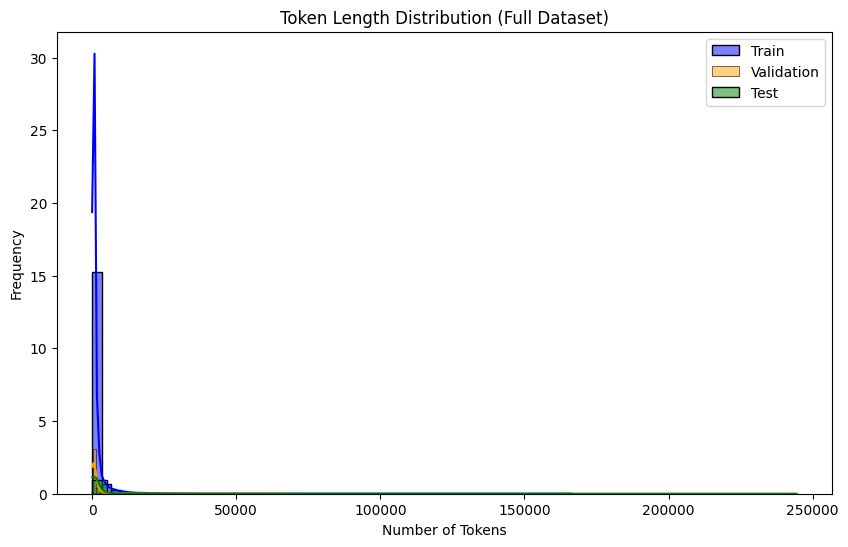

/tmp/ipython-input-2875091304.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_label_names, y=top_labels.values, palette='Blues_d')


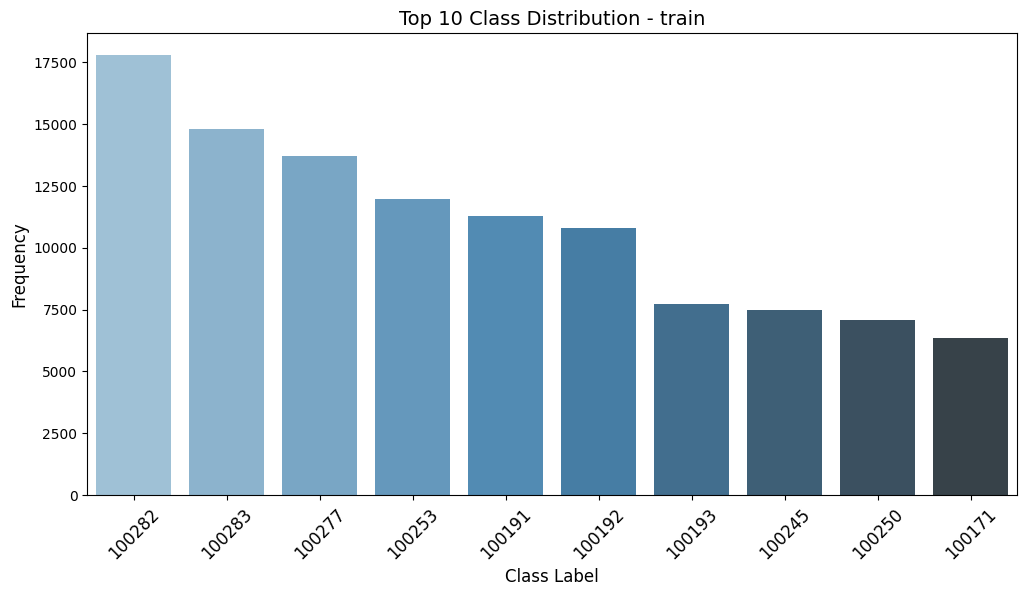

/tmp/ipython-input-2875091304.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_label_names, y=bottom_labels.values, palette='Reds_d')


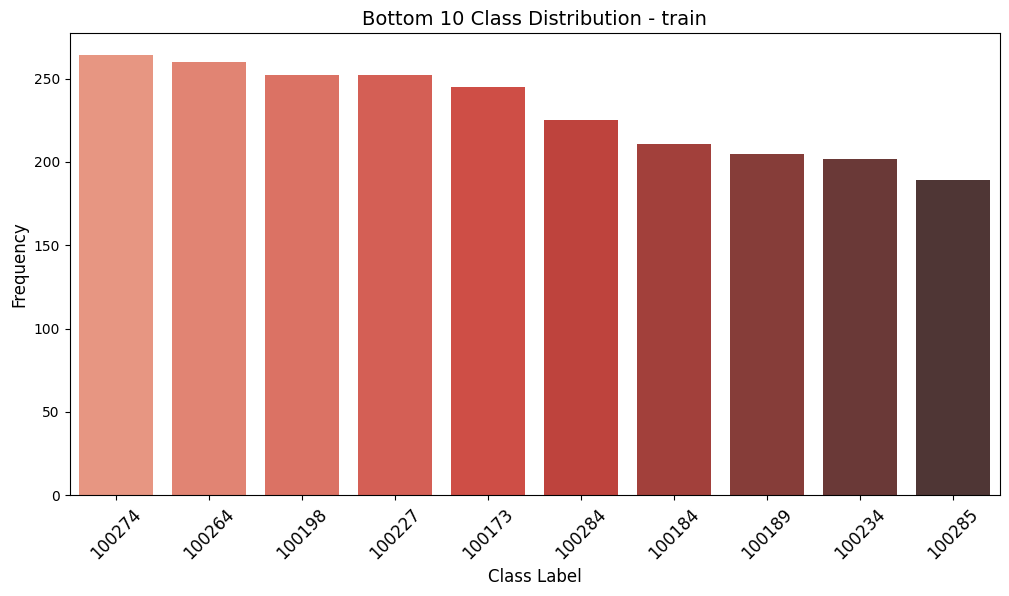

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import chain  # for multi-label flattening

# 1️⃣ Plot token length distribution
def plot_token_length_distribution(dataset, title='Token Length Distribution'):
    plt.figure(figsize=(10,6))
    for subset, color in zip(['train', 'validation', 'test'], ['blue', 'orange', 'green']):
        lengths = dataset[subset]['num_tokens']
        sns.histplot(
            lengths,
            bins=50,
            kde=True,
            label=subset.capitalize(),
            color=color,
            stat="frequency",
            alpha=0.5
        )
    plt.title(title)
    plt.xlabel('Number of Tokens')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

# 2️⃣ Plot class distribution for multi-label dataset
def plot_class_distribution(dataset, split='train', top_n=10):
    # Flatten all labels since it's multi-label
    all_labels = list(chain.from_iterable(dataset[split]['labels']))
    label_counts = pd.Series(all_labels).value_counts()

    # Top N labels
    top_labels = label_counts.head(top_n)
    top_label_names = [label_list[i] for i in top_labels.index]

    # Bottom N labels
    bottom_labels = label_counts.tail(top_n)
    bottom_label_names = [label_list[i] for i in bottom_labels.index]

    # Plot top N classes
    plt.figure(figsize=(12,6))
    sns.barplot(x=top_label_names, y=top_labels.values, palette='Blues_d')
    plt.xticks(rotation=45, fontsize=12)
    plt.title(f'Top {top_n} Class Distribution - {split}', fontsize=14)
    plt.xlabel('Class Label', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()

    # Plot bottom N classes
    plt.figure(figsize=(12,6))
    sns.barplot(x=bottom_label_names, y=bottom_labels.values, palette='Reds_d')
    plt.xticks(rotation=45, fontsize=12)
    plt.title(f'Bottom {top_n} Class Distribution - {split}', fontsize=14)
    plt.xlabel('Class Label', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()


# Before plotting token lengths, compute them
for split in ['train', 'validation', 'test']:
    dataset[split] = dataset[split].map(
        lambda x: {'num_tokens': len(tokenizer(x['text'])['input_ids'])}
    )

# Plot token length distribution
plot_token_length_distribution(dataset, title="Token Length Distribution (Full Dataset)")

# Plot class distribution
plot_class_distribution(dataset, 'train')


Extract text from PDF

In [11]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 29.8 MB/s eta 0:00:00


In [13]:
import pdfplumber

def extract_text_from_pdf(pdf_path):
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text += page.extract_text() + "\n"
    return text

# Example usage
pdf_text = extract_text_from_pdf("/content/sample contarct 3.pdf")
print(pdf_text[:1000])  # preview first 1000 characters


SAAS TERMS OF SERVICE
CYBERARK SOFTWARE LTD. AND/OR ITS AFFILIATES (“CYBERARK”) IS WILLING TO GRANT ACCESS TO
THE SAAS PRODUCTS TO YOU AS THE COMPANY OR THE LEGAL ENTITY THAT WILL BE UTILIZING THE
SAAS PRODUCTS (REFERENCED BELOW AS “CUSTOMER”) ON THE CONDITION THAT YOU ACCEPT ALL
OF THE TERMS OF THIS AGREEMENT (AS DEFINED BELOW). BY ENTERING INTO THIS AGREEMENT ON
BEHALF OF THE CUSTOMER, YOU REPRESENT THAT YOU HAVE THE LEGAL AUTHORITY TO BIND THE
CUSTOMER TO THIS AGREEMENT. CUSTOMER AND CYBERARK MAY EACH ALSO BE REFERRED TO AS
A “PARTY” AND TOGETHER, THE “PARTIES”.
PLEASE READ THIS AGREEMENT CAREFULLY BEFORE USING THE SAAS PRODUCTS. THIS SAAS TERMS
OF SERVICE (“AGREEMENT”) CONSTITUTES A LEGAL AND ENFORCEABLE CONTRACT BETWEEN
CUSTOMER AND CYBERARK. BY INDICATING CONSENT ELECTRONICALLY, OR ACCESSING OR
OTHERWISE USING THE SAAS PRODUCTS, CUSTOMER AGREES TO THE TERMS AND CONDITIONS OF
THIS AGREEMENT. IF CUSTOMER DOES NOT AGREE TO THIS AGREEMENT, DO NOT INDICATE CONSENT
ELECTRONICALLY AND M

Simplify Legal Jargon

Load Pretrained Legal-BERT (Fine-Tuned on LEDGAR)

In [14]:
from transformers import pipeline

simplifier = pipeline("text2text-generation", model="t5-small")

simplified = simplifier(
    "Simplify this legal text: " + summary[0]['summary_text'],
    max_length=200
)

print(simplified[0]['generated_text'])


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Device set to use cpu


NameError: name 'summary' is not defined

Wrap into a Function

In [17]:
def summarize_legal_document(pdf_path):
    # Extract text
    text = extract_text_from_pdf(pdf_path)

    # Summarize (legal → short form)
    summary = summarizer(text[:2000], max_length=250, min_length=100, do_sample=False)

    # Simplify language
    simplified = simplifier(
        "Simplify this legal text: " + summary[0]['summary_text'],
        max_length=200
    )

    return simplified[0]['generated_text']


In [15]:
from transformers import pipeline

# Load a summarization pipeline
summarizer = pipeline("summarization", model="t5-small")

# Summarize the extracted text (using a portion of the text for efficiency)
# You can adjust max_length and min_length as needed
summary = summarizer(pdf_text[:2000], max_length=250, min_length=100, do_sample=False)

print("Original text (first 500 chars):")
print(pdf_text[:500])
print("\nGenerated Summary:")
print(summary[0]['summary_text'])

Device set to use cpu
Token indices sequence length is longer than the specified maximum sequence length for this model (607 > 512). Running this sequence through the model will result in indexing errors
Both `max_new_tokens` (=256) and `max_length`(=250) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Original text (first 500 chars):
SAAS TERMS OF SERVICE
CYBERARK SOFTWARE LTD. AND/OR ITS AFFILIATES (“CYBERARK”) IS WILLING TO GRANT ACCESS TO
THE SAAS PRODUCTS TO YOU AS THE COMPANY OR THE LEGAL ENTITY THAT WILL BE UTILIZING THE
SAAS PRODUCTS (REFERENCED BELOW AS “CUSTOMER”) ON THE CONDITION THAT YOU ACCEPT ALL
OF THE TERMS OF THIS AGREEMENT (AS DEFINED BELOW). BY ENTERING INTO THIS AGREEMENT ON
BEHALF OF THE CUSTOMER, YOU REPRESENT THAT YOU HAVE THE LEGAL AUTHORITY TO BIND THE
CUSTOMER TO THIS AGREEMENT. CUSTOMER AND CYBERARK

Generated Summary:
CUSTOMER AND CYBERARK MAY EACH ALSO BE REFERRED TO AS a “PARTY” AND TOGETHER, THE “PARTIES” . CyberArk grants Customer a non-exclusive, non- transferable right to access and use the SaaS Products and applicable Documentation solely for Customer’s and its affiliates’ internal business purposes . if CUSToMER DOES NOT AGREE TO THIS AGREEMENT, DO NOT INDICATE CONSENT ELECT


Highlight Important Clauses

Rule-based patterns

In [18]:
import re

def highlight_clauses(text):
    highlights = {
        "Obligations": re.findall(r"(?:shall|must|agree to|is required to)[^.]+", text, flags=re.IGNORECASE),
        "Penalties": re.findall(r"(?:penalty|fine|breach|liable for)[^.]+", text, flags=re.IGNORECASE),
        "Auto-renewals": re.findall(r"(?:automatically renew|renewal|extended for)[^.]+", text, flags=re.IGNORECASE),
        "Termination": re.findall(r"(?:terminate|termination|end this agreement)[^.]+", text, flags=re.IGNORECASE),
        "One-sided terms": re.findall(r"(?:only.*may|sole discretion|not liable)[^.]+", text, flags=re.IGNORECASE),
    }
    return highlights

# Example usage
clauses = highlight_clauses(pdf_text)
for category, matches in clauses.items():
    print(f"\n🔹 {category}:")
    for m in matches[:3]:  # show first 3
        print("   -", m.strip())



🔹 Obligations:
   - AGREE TO THIS AGREEMENT, DO NOT INDICATE CONSENT
ELECTRONICALLY AND MAKE NO FURTHER USE OF THE SAAS PRODUCTS
   - shall not (directly or indirectly): (a) copy or reproduce the SaaS
Products or the Documentation except as permitted under this Agreement; (b) exceed the subscribed quantities,
Authorized Users or other entitlement measures of the SaaS Products as set forth in the applicable Order; (c)
remove or destroy any copyright, trademark or other proprietary marking or legends placed on or contained in the
SaaS Products, Documentation or CyberArk Intellectual Property; (d) assign, sell, sublicense, distribute or
otherwise transfer or make available the rights granted to Customer under this Agreement to any third party except
as expressly set forth herein; (e) modify, reverse engineer or disassemble the SaaS Products; (f) except to the
limited extent applicable laws specifically prohibit such restriction, decompile, attempt to derive the source code or
underlying 

ML/NLP-based (more advanced, Legal-BERT + NER)

In [22]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

model_name = "nlpaueb/legal-bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_clause_types)


NameError: name 'num_clause_types' is not defined

In [23]:
# Define the number of clause types based on your categories
num_clause_types = 5 # For Obligations, Penalties, Auto-renewals, Termination, One-sided terms

In [24]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

model_name = "nlpaueb/legal-bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_clause_types)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Save model

In [25]:
model.save_pretrained("./legalbert-ledgar")
tokenizer.save_pretrained("./legalbert-ledgar")


('./legalbert-ledgar/tokenizer_config.json',
 './legalbert-ledgar/special_tokens_map.json',
 './legalbert-ledgar/vocab.txt',
 './legalbert-ledgar/added_tokens.json',
 './legalbert-ledgar/tokenizer.json')

In [26]:
clause_classifier = pipeline("text-classification", model="./legalbert-ledgar", tokenizer="./legalbert-ledgar")


Device set to use cpu


Quick Regex-Based Highlighting (No Training Needed)

In [27]:
import re

def highlight_clauses(text):
    highlights = {
        "Obligations": re.findall(r"(?:shall|must|agree to|is required to)[^.]+", text, flags=re.IGNORECASE),
        "Penalties": re.findall(r"(?:penalty|fine|breach|liable for)[^.]+", text, flags=re.IGNORECASE),
        "Auto-renewals": re.findall(r"(?:automatically renew|renewal|extended for)[^.]+", text, flags=re.IGNORECASE),
        "Termination": re.findall(r"(?:terminate|termination|end this agreement)[^.]+", text, flags=re.IGNORECASE),
        "One-sided terms": re.findall(r"(?:only.*may|sole discretion|not liable)[^.]+", text, flags=re.IGNORECASE),
    }
    return highlights

clauses = highlight_clauses(pdf_text)
for category, matches in clauses.items():
    print(f"\n🔹 {category}:")
    for m in matches[:3]:
        print("   -", m.strip())



🔹 Obligations:
   - AGREE TO THIS AGREEMENT, DO NOT INDICATE CONSENT
ELECTRONICALLY AND MAKE NO FURTHER USE OF THE SAAS PRODUCTS
   - shall not (directly or indirectly): (a) copy or reproduce the SaaS
Products or the Documentation except as permitted under this Agreement; (b) exceed the subscribed quantities,
Authorized Users or other entitlement measures of the SaaS Products as set forth in the applicable Order; (c)
remove or destroy any copyright, trademark or other proprietary marking or legends placed on or contained in the
SaaS Products, Documentation or CyberArk Intellectual Property; (d) assign, sell, sublicense, distribute or
otherwise transfer or make available the rights granted to Customer under this Agreement to any third party except
as expressly set forth herein; (e) modify, reverse engineer or disassemble the SaaS Products; (f) except to the
limited extent applicable laws specifically prohibit such restriction, decompile, attempt to derive the source code or
underlying 

Flagging Red Flags in Contracts

Rule based

In [38]:
import re

def flag_red_flags(text):
    risks = {
        "Excessive Penalties": re.findall(r"(?:penalty|fine|interest of \d+%|liquidated damages)[^.]+", text, flags=re.IGNORECASE),
        "Auto-Renewals": re.findall(r"(?:automatically renew|renewal|extended for)[^.]+", text, flags=re.IGNORECASE),
        "One-Sided Terms": re.findall(r"(?:only.*may|sole discretion|not liable|without liability)[^.]+", text, flags=re.IGNORECASE),
        "Broad Obligations": re.findall(r"(?:indemnify|hold harmless|any damages|all losses)[^.]+", text, flags=re.IGNORECASE),
        "Ambiguous Language": re.findall(r"(?:reasonable efforts|best efforts|as soon as practicable)[^.]+", text, flags=re.IGNORECASE),
    }
    return risks

risks = flag_red_flags(pdf_text)

for category, matches in risks.items():
    if matches:
        print(f"\n⚠️ {category}:")
        for m in matches[:3]:
            print("   -", m.strip())



⚠️ Excessive Penalties:
   - FINED BELOW)
   - fined in the Business Associate Agreement (“BAA”)) in Customer Data,
the Parties shall comply with the BAA found at https://www
   - fined in sub-paragraph (a)(1) of DFARS
section 252

⚠️ One-Sided Terms:
   - sole discretion (collectively, “Trial Services”), CyberArk
makes such Trial Services available to Customer until the earlier of: (i) the end of the free trial or proof of concept
period or beta testing period as communicated by CyberArk or specified in an Order; (ii) the start date of any
purchased version of such SaaS Products; or (iii) written notice of termination from CyberArk (“Trial Services
Period”)

⚠️ Broad Obligations:
   - indemnify, defend, or hold harmless under this Agreement are not applicable to Customers using Trial
Services
   - indemnify Customer and/or its Affiliates and their
officers, directors and employees against all third-party claims, suits and proceedings and all directly related losses,
liabilities, dama

ML-Based Approach

In [45]:
import pdfplumber

def extract_text_from_pdf(pdf_path):
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            if page.extract_text():
                text += page.extract_text() + "\n"
    return text

# Example usage
pdf_text = extract_text_from_pdf("/content/sample contarct 3.pdf")


In [46]:
risks = flag_red_flags(pdf_text)
for category, matches in risks.items():
    if matches:
        print(f"\n⚠️ {category}:")
        for m in matches[:3]:
            print("   -", m.strip())



⚠️ Excessive Penalties:
   - FINED BELOW)
   - fined in the Business Associate Agreement (“BAA”)) in Customer Data,
the Parties shall comply with the BAA found at https://www
   - fined in sub-paragraph (a)(1) of DFARS
section 252

⚠️ One-Sided Terms:
   - sole discretion (collectively, “Trial Services”), CyberArk
makes such Trial Services available to Customer until the earlier of: (i) the end of the free trial or proof of concept
period or beta testing period as communicated by CyberArk or specified in an Order; (ii) the start date of any
purchased version of such SaaS Products; or (iii) written notice of termination from CyberArk (“Trial Services
Period”)

⚠️ Broad Obligations:
   - indemnify, defend, or hold harmless under this Agreement are not applicable to Customers using Trial
Services
   - indemnify Customer and/or its Affiliates and their
officers, directors and employees against all third-party claims, suits and proceedings and all directly related losses,
liabilities, dama

Legal Q&A from the Contract

QA Pipeline

In [47]:
from transformers import pipeline

qa_pipeline = pipeline("question-answering", model="deepset/roberta-base-squad2")

def answer_question(question, context):
    result = qa_pipeline(question=question, context=context)
    return result['answer']

# Example usage
question = "Can I terminate this contract early?"
answer = answer_question(question, pdf_text[:2000])  # use first part of text
print(f"Q: {question}\nA: {answer}")


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Device set to use cpu


Q: Can I terminate this contract early?
A: IF CUSTOMER DOES NOT AGREE TO THIS AGREEMENT


Adding Chunking + Retrieval

In [48]:
from transformers import AutoTokenizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Embedder for semantic search
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def chunk_text(text, chunk_size=500):
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

chunks = chunk_text(pdf_text, chunk_size=200)

# Pre-compute embeddings
chunk_embeddings = embedder.encode(chunks)

def retrieve_relevant_chunk(question):
    q_embedding = embedder.encode([question])
    sims = cosine_similarity(q_embedding, chunk_embeddings)[0]
    best_idx = np.argmax(sims)
    return chunks[best_idx]

def legal_qa(question):
    best_chunk = retrieve_relevant_chunk(question)
    result = qa_pipeline(question=question, context=best_chunk)
    return result['answer'], best_chunk

# Example
q = "Can I terminate this contract early?"
ans, ctx = legal_qa(q)
print(f"Q: {q}\nA: {ans}\n\n(Context: {ctx[:200]}...)")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Q: Can I terminate this contract early?
A: Either Party may terminate this Agreement immediately upon notice to the other Party

(Context: then applicable professional services terms. 12. Term and Termination 12.1. Term. This Agreement will be effective upon Customer’s first access of a SaaS Product and shall remain in force during the a...)


In [52]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.2 MB/s eta 0:00:00


In [58]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 4.1 MB/s eta 0:00:00


testing

In [64]:
from transformers import pipeline, AutoTokenizer, AutoModelForQuestionAnswering
import PyPDF2

# Load a pre-trained Question Answering model
model_name = "distilbert-base-uncased-distilled-squad"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

# Create a QA pipeline
qa_pipeline = pipeline("question-answering", model=model, tokenizer=tokenizer)

# Function to extract text from PDF
def extract_text_from_pdf(pdf_path):
    text = ""
    with open(pdf_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            text += page.extract_text() + "\n"
    return text

# Load contract PDF
contract_text = extract_text_from_pdf("/content/sample contarct 3.pdf")  # replace with your PDF path

# Function to answer user questions
def answer_question(question, context=contract_text):
    result = qa_pipeline(question=question, context=context)
    answer = result['answer']
    score = result['score']
    return {"answer": answer, "confidence": score}

# Example usage
user_question = input("Enter your legal question: ")
response = answer_question(user_question)
print(f"Answer: {response['answer']}")
print(f"Confidence: {response['confidence']:.2f}")


Device set to use cpu


Enter your legal question: Are there hidden charges for breaking this contract?
Answer: The contract may be terminated early if either party provides 30 days written notice
Confidence: 0.21


In [68]:
from transformers import pipeline, AutoTokenizer, AutoModelForQuestionAnswering
import PyPDF2

# Load a pre-trained Question Answering model
model_name = "distilbert-base-uncased-distilled-squad"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

# Create a QA pipeline
qa_pipeline = pipeline("question-answering", model=model, tokenizer=tokenizer)

# Function to extract text from PDF
def extract_text_from_pdf(pdf_path):
    text = ""
    with open(pdf_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            text += page.extract_text() + "\n"
    return text

# Load contract PDF
contract_text = extract_text_from_pdf("/content/sample contarct 3.pdf")  # replace with your PDF path

# Function to answer user questions
def answer_question(question, context=contract_text):
    result = qa_pipeline(question=question, context=context)
    answer = result['answer']
    score = result['score']
    return {"answer": answer, "confidence": score}

# Example usage
user_question = input("Enter your legal question: ")
response = answer_question(user_question)
print(f"Answer: {response['answer']}")
print(f"Confidence: {response['confidence']:.2f}")


Device set to use cpu


Enter your legal question: Can I terminate this contract early?
Answer: terminate the affected Order
Confidence: 0.18


In [49]:
def legal_qa_with_confidence(question):
    best_chunk = retrieve_relevant_chunk(question)
    result = qa_pipeline(question=question, context=best_chunk)
    answer = result['answer']
    confidence = result['score']
    if confidence < 0.5:
        answer += " ⚠️ (Low confidence. Please consult a lawyer.)"
    return answer, confidence

q = "Who pays for damages?"
ans, conf = legal_qa_with_confidence(q)
print(f"Answer: {ans} (Confidence: {conf:.2f})")


Answer: CyberArk ⚠️ (Low confidence. Please consult a lawyer.) (Confidence: 0.00)


Confidence + Lawyer Recommendation

In [50]:
def legal_qa_with_confidence(question):
    best_chunk = retrieve_relevant_chunk(question)
    result = qa_pipeline(question=question, context=best_chunk)

    answer = result['answer']
    confidence = result['score']

    # Add recommendation
    if confidence < 0.5:
        note = "⚠️ Low confidence. Please consult a lawyer for accurate advice."
    else:
        note = "✅ This answer is based on the document, but consider legal advice for critical matters."

    return {
        "question": question,
        "answer": answer,
        "confidence": round(confidence, 2),
        "note": note
    }

# Example
q = "Can I terminate this contract early?"
response = legal_qa_with_confidence(q)
print(response)


{'question': 'Can I terminate this contract early?', 'answer': 'Either Party may terminate this Agreement immediately upon notice to the other Party', 'confidence': 0.08, 'note': '⚠️ Low confidence. Please consult a lawyer for accurate advice.'}
